In [4]:
import numpy as np 
import pandas as pd 

from matplotlib import pyplot as plt
import seaborn as sns

import wandb

from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
wandbapi = user_secrets.get_secret("wandb")

wandb.login(wandbapi)


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: t-kholodov (t-kholodov-hse-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

---

# Тестовый датасет

---

In [6]:
api = wandb.Api()
runs = api.runs('iadProject')

runs_df = pd.DataFrame([])

words = []

summary_list, config_list, name_list = [], [], []
for run in runs:
    summary_list.append({k.replace('_',''): v for k,v in run.summary._json_dict.items()})
    config_list.append({k: v for k,v in run.config.items() if not k.startswith("_")})
    name_list.append({'name': run.name})
    run_df = pd.DataFrame([{k: v if type(v) != dict else list(v.values())[0] for i in summary_list + config_list + name_list for k,v in i.items()}]).set_index('name')
    artifacts = run.logged_artifacts()[0].get("unpredicted_overpredicted")
    try:
        run_df['unpredicted']= [artifacts.get_dataframe()['unpredicted'].explode().dropna().to_list()]
        run_df['overpredicted']= [artifacts.get_dataframe()['overpredicted'].explode().dropna().to_list()]  
    except:
        pass
    runs_df = pd.concat([runs_df, run_df])
    
runs_df



wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  


,runtime,step,timestamp,wandb,technical/errorrate,technical/totaltime,text/accuracy,toponyms/f,toponyms/precision,toponyms/recall,...,temp_geo,temp_recog,max_tokens_geo,max_tokens_recog,context_window_geo,context_window_recog,usage/cache,usage/inputtokens,usage/outputtokens,local
name,,,,,,,,,,,,,,,,,,,,,
ApexOptimalI-ctx4096-mt512-t01,3013.000000,311,1.779706e+09,3013,24,7.680361,0.708333,0.693809,0.578605,0.866295,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Qwen3.6-35B-A3B-NN-mt512-t01,2406.000000,311,1.779716e+09,2406,12,6.931241,0.727564,0.731335,0.640267,0.852605,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GigaChat3.1-10B-mt512-t01,1703.000000,311,1.779721e+09,1703,7,5.649289,0.445513,0.429530,0.448808,0.411840,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
classic_NER__natasha,12.000000,311,1.779908e+09,12,0,0.030908,0.516026,0.470337,0.417457,0.538556,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
classic_NER__spacy,40.000000,311,1.779908e+09,40,0,0.123392,0.538462,0.474937,0.405009,0.574051,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
classic_NER__stanza,55.000000,311,1.779909e+09,55,0,0.171650,0.503205,0.487640,0.450675,0.531212,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
classic_NER__hf_gherman,14.000000,311,1.779909e+09,14,0,0.041856,0.416667,0.369628,0.445596,0.315789,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
classic_NER__hf_wikineural,15.000000,311,1.779909e+09,15,0,0.042777,0.448718,0.466576,0.526965,0.418605,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Qwen3.6-35A3-M-Agent,5088.000000,311,1.781013e+09,5088,10,16.298501,0.490385,0.698758,0.842697,0.596817,...,0.1,0.7,512.0,512.0,4096.0,4096.0,NaN,NaN,NaN,NaN


In [13]:
runs_df[runs_df.index == 'gpt-5.4-mini']

,runtime,step,timestamp,wandb,technical/errorrate,technical/totaltime,text/accuracy,toponyms/f,toponyms/precision,toponyms/recall,...,temp_geo,temp_recog,max_tokens_geo,max_tokens_recog,context_window_geo,context_window_recog,usage/cache,usage/inputtokens,usage/outputtokens,local
name,,,,,,,,,,,,,,,,,,,,,
gpt-5.4-mini,1473.0,311,1.781151e+09,1473,0,4.71548,0.541667,0.751557,0.86465,0.664627,...,0.1,0.7,512.0,512.0,4096.0,4096.0,1224704.0,1127413.0,36084.0,False


In [21]:
final_exp = runs_df[(runs_df.index.isin(['gpt-5.4-mini', 'Qwen3.6-35B-A3B-GGUF'])) & (runs_df.step == 311)]
final_exp

,runtime,step,timestamp,wandb,technical/errorrate,technical/totaltime,text/accuracy,toponyms/f,toponyms/precision,toponyms/recall,...,temp_geo,temp_recog,max_tokens_geo,max_tokens_recog,context_window_geo,context_window_recog,usage/cache,usage/inputtokens,usage/outputtokens,local
name,,,,,,,,,,,,,,,,,,,,,
gpt-5.4-mini,1473.0,311,1.781151e+09,1473,0,4.715480,0.541667,0.751557,0.86465,0.664627,...,0.1,0.7,512.0,512.0,4096.0,4096.0,1224704.0,1127413.0,36084.0,False
Qwen3.6-35B-A3B-GGUF,4769.0,311,1.781158e+09,4769,11,15.277442,0.467949,0.678261,0.83301,0.572000,...,0.1,0.7,512.0,512.0,4096.0,4096.0,0.0,0.0,0.0,True


In [73]:
 plt.style.use('dark_background')

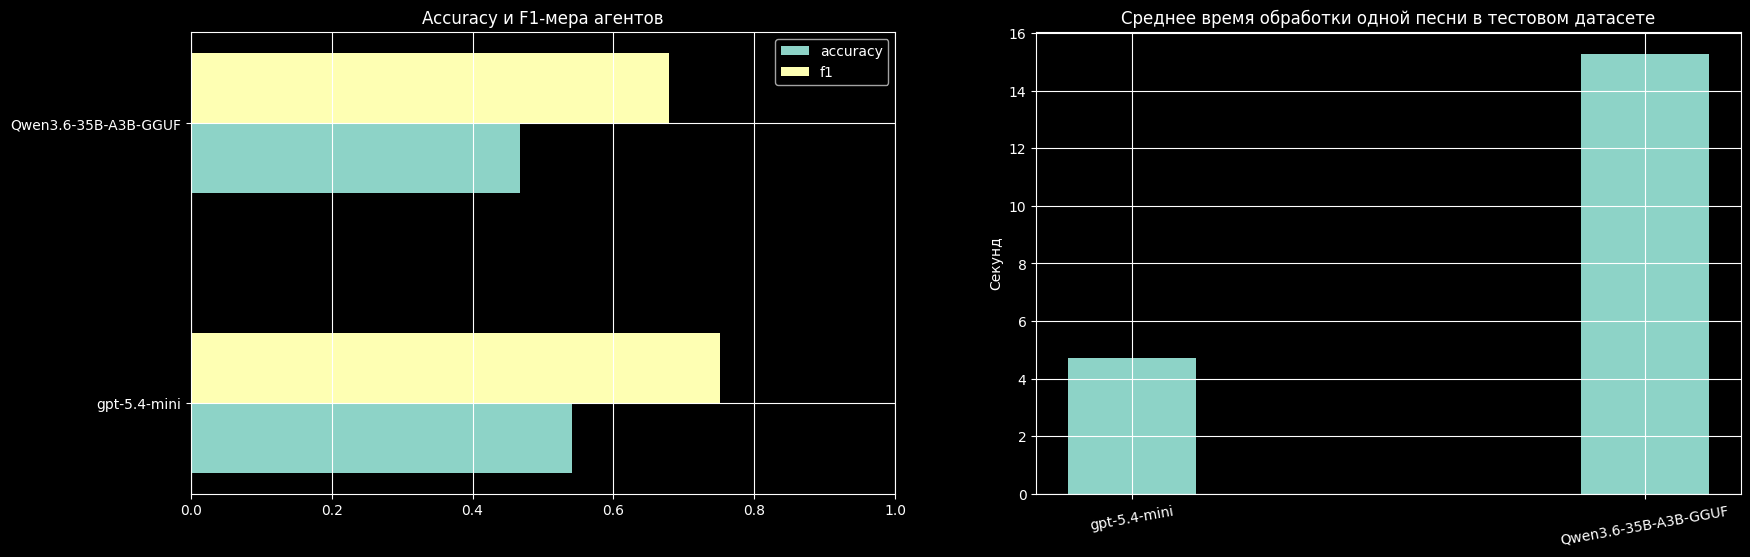

In [74]:
fig, ax = plt.subplots(1,2, figsize = (20,6))

multiplier = 0.25

tests = np.arange(len(final_exp))

accuracy = ax[0].barh(y = tests, width = final_exp['text/accuracy'], height = multiplier, label = 'accuracy')
f = ax[0].barh(y = tests + multiplier, width = final_exp['toponyms/f'], height = multiplier, label = 'f1')


ax[0].set_yticks(tests + (multiplier/2));
ax[0].set_yticklabels(final_exp.index);
ax[0].set_xlim([0,1])

ax[0].legend();
ax[0].grid()
ax[0].set_title('Accuracy и F1-мера агентов');

ax[1].bar(x = tests, height = final_exp['technical/totaltime'], width = multiplier)
ax[1].set_xticks(tests);
ax[1].set_xticklabels(final_exp.model, rotation = 10);
ax[1].set_ylabel('Секунд')
ax[1].grid()
ax[1].set_title('Среднее время обработки одной песни в тестовом датасете');

In [ ]:
 and recall

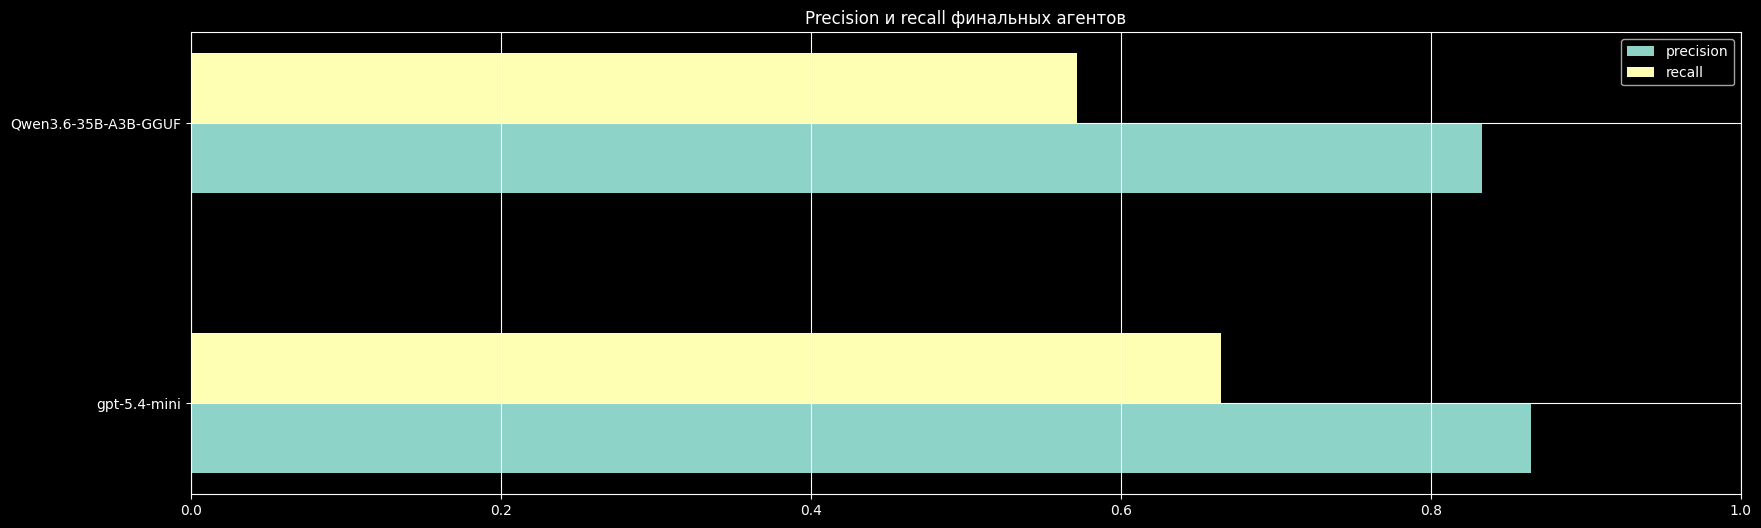

In [75]:
fig, ax = plt.subplots(1,1, figsize = (20,6))

multiplier = 0.25

tests = np.arange(len(final_exp))

pres = ax.barh(y = tests, width = final_exp['toponyms/precision'], height = multiplier, label = 'precision')
recall = ax.barh(y = tests + multiplier, width = final_exp['toponyms/recall'], height = multiplier, label = 'recall')

ax.set_yticks(tests + (multiplier/2));
ax.set_yticklabels(final_exp.index);
ax.set_xlim([0,1])

ax.legend();
ax.grid()
ax.set_title('Precision и recall финальных агентов');


(np.float64(-0.5), np.float64(4999.5), np.float64(2999.5), np.float64(-0.5))

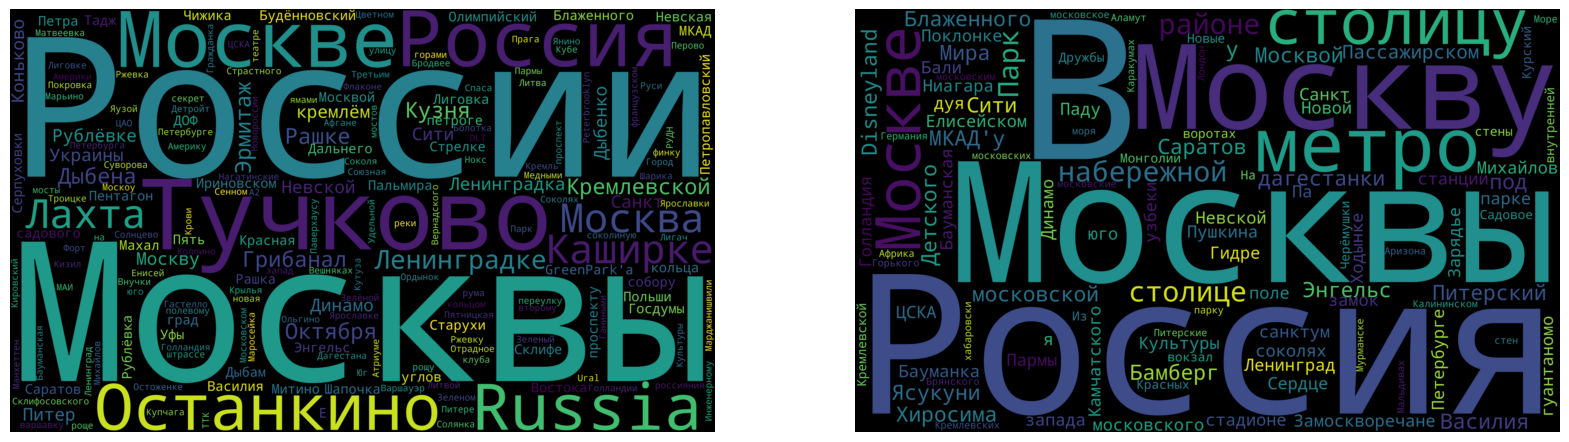

In [72]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,2, figsize = (20,6))


wordcloud = WordCloud(scale = 5, width = 1000, height = 600).generate(" ".join(final_exp[final_exp.index == 'gpt-5.4-mini'].loc['gpt-5.4-mini','unpredicted']));
wordcloud2 = WordCloud(scale = 5, width = 1000, height = 600).generate(" ".join(final_exp[final_exp.index == 'gpt-5.4-mini'].loc['gpt-5.4-mini','overpredicted']));

ax[0].imshow(wordcloud, interpolation='bilinear')
ax[1].imshow(wordcloud2, interpolation='bilinear')
ax[0].axis("off")
ax[1].axis("off")

Text(0, 0.5, 'Количество токенов, млн')

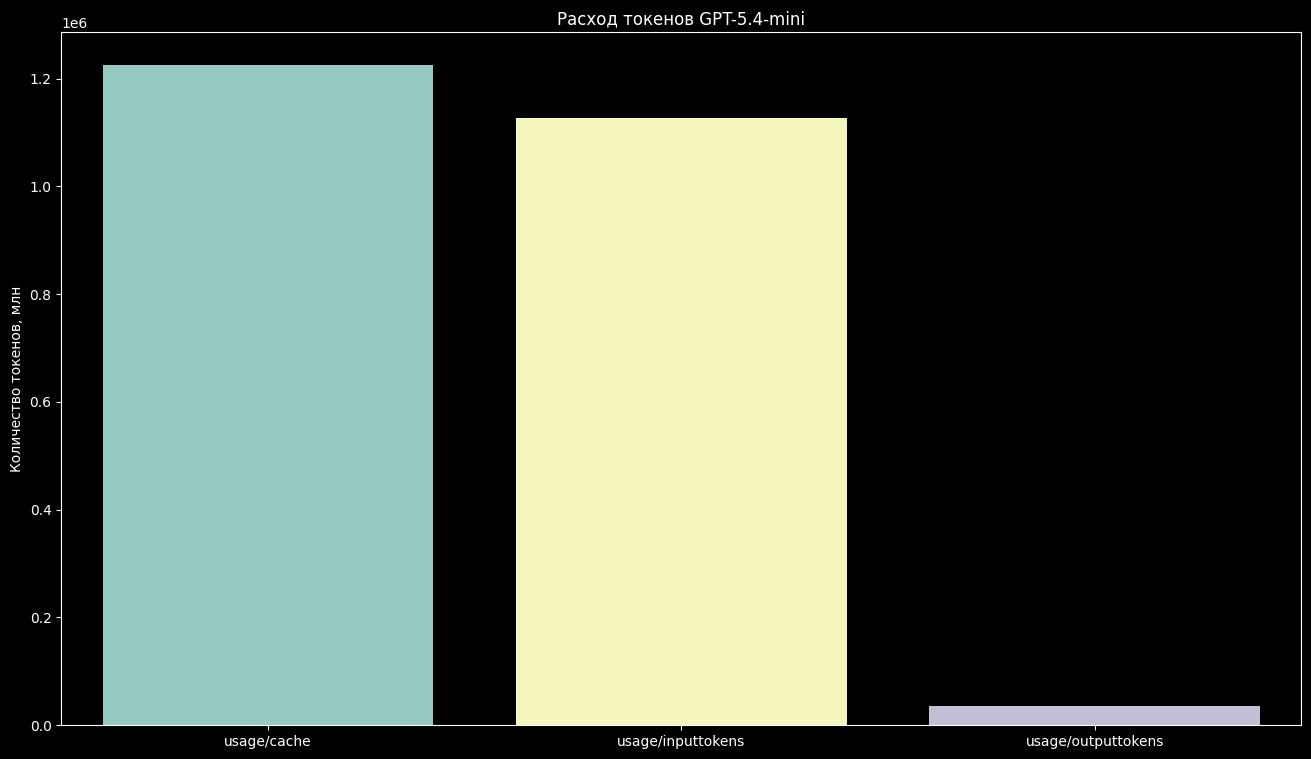

In [95]:
import seaborn as sns
plt.figure(figsize = (16,9))
sns.barplot(final_exp[final_exp.index == 'gpt-5.4-mini'][['usage/cache', 'usage/inputtokens', 'usage/outputtokens']])
plt.title('Расход токенов GPT-5.4-mini')
plt.ylabel('Количество токенов, млн')
